In [20]:
# Step 1: Mount Google Drive
# We connect Google Colab with Google Drive to access dataset files

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Step 2: Load Dataset
# We read the CSV file from Google Drive into a DataFrame for processing

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Walmart_data/Walmart_Sales.csv')

# Display first 5 rows
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [22]:
# Step 3: Check Data
# We analyze the dataset structure, data types, and missing values

# Show basic information about dataset
df.info()

# Check number of missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [23]:
# Step 4: Handle Missing Values
# Fill missing values using forward fill method

df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_5365/187112215.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [24]:
# Step 5: Fix Date Column
# Convert Date to datetime and clean invalid values

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date'], inplace=True)

# Sort by date (important for time-series)
df = df.sort_values(by='Date')

# Reset index
df.reset_index(drop=True, inplace=True)

In [25]:
# Step 6: Feature Engineering
# Create new features from Date and past sales

# Time features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week.astype(int)
df['day'] = df['Date'].dt.day

# Lag features (previous sales)
df['lag_1'] = df['Weekly_Sales'].shift(1)
df['lag_2'] = df['Weekly_Sales'].shift(2)

# Rolling mean (trend)
df['rolling_mean'] = df['Weekly_Sales'].rolling(window=3).mean()

# Drop rows with missing values
df.dropna(inplace=True)

In [26]:
# Step 7: Define Features and Target
# X = input features, y = target variable

X = df.drop(['Weekly_Sales', 'Date'], axis=1)
y = df['Weekly_Sales']

In [27]:
# Step 8: Train-Test Split
# Split data into training and testing (no shuffle for time-series)

split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [28]:
# Step 9: Random Forest Model
# Train machine learning model to predict sales

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 88446.10915594548
RMSE: 126713.47432289299


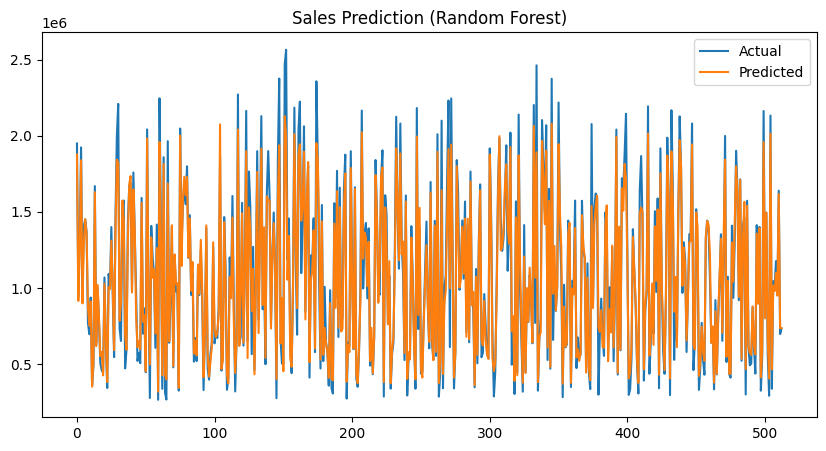

In [29]:
# Step 10: Visualization
# Compare actual vs predicted sales

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Sales Prediction (Random Forest)")
plt.show()

In [30]:
# Step 11: Save Model
# Save trained model for frontend use

import pickle

with open('sales_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [31]:
# Step 12: Download Model
# Download model file to your system

from google.colab import files
files.download('sales_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>